In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('insurance.csv')

In [5]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [19]:
df.shape

(1340, 10)

In [15]:
pd.set_option("display.float_format", "{:.2f}".format)

In [17]:
sns.set(style='whitegrid', palette='Set2', font_scale=1.1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [9]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1340.000000,1335.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,670.500000,38.078652,30.668955,94.157463,1.093284,13252.745642
std,386.968991,11.102924,6.106735,11.434712,1.205334,12109.609288
min,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,335.750000,29.000000,26.275000,86.000000,0.000000,4719.685000
50%,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [10]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.dropna(inplace=True)

In [28]:
df.drop(columns=['Id'])

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,24.00,male,30.10,87,No,0,No,southeast,1131.51
7,19.00,male,41.10,100,No,0,No,northwest,1146.80
8,20.00,male,43.00,86,No,0,No,northwest,1149.40
9,30.00,male,53.10,97,No,0,No,northwest,1163.46
...,...,...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [29]:
numeric_cols = ['age', 'bmi', 'bloodpressure', 'children', 'claim']
categorical_cols = ['gender', 'diabetic', 'smoker', 'region']

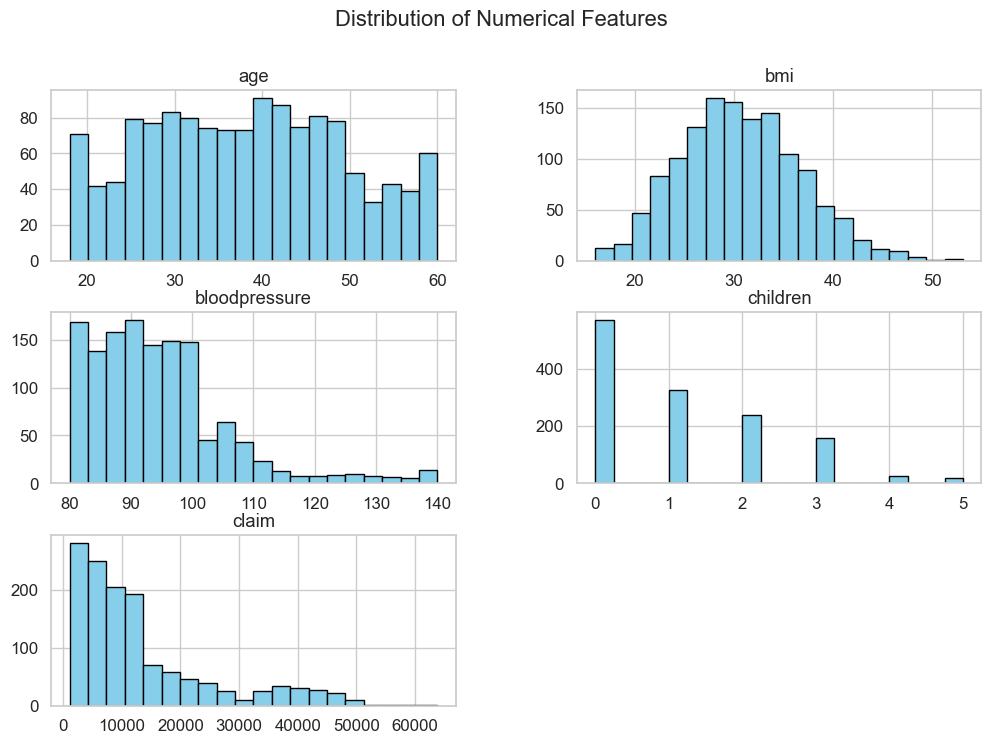

In [32]:
df[numeric_cols].hist(bins=20, figsize=(12,8), color="skyblue", edgecolor="black")
plt.suptitle('Distribution of Numerical Features')
plt.show()

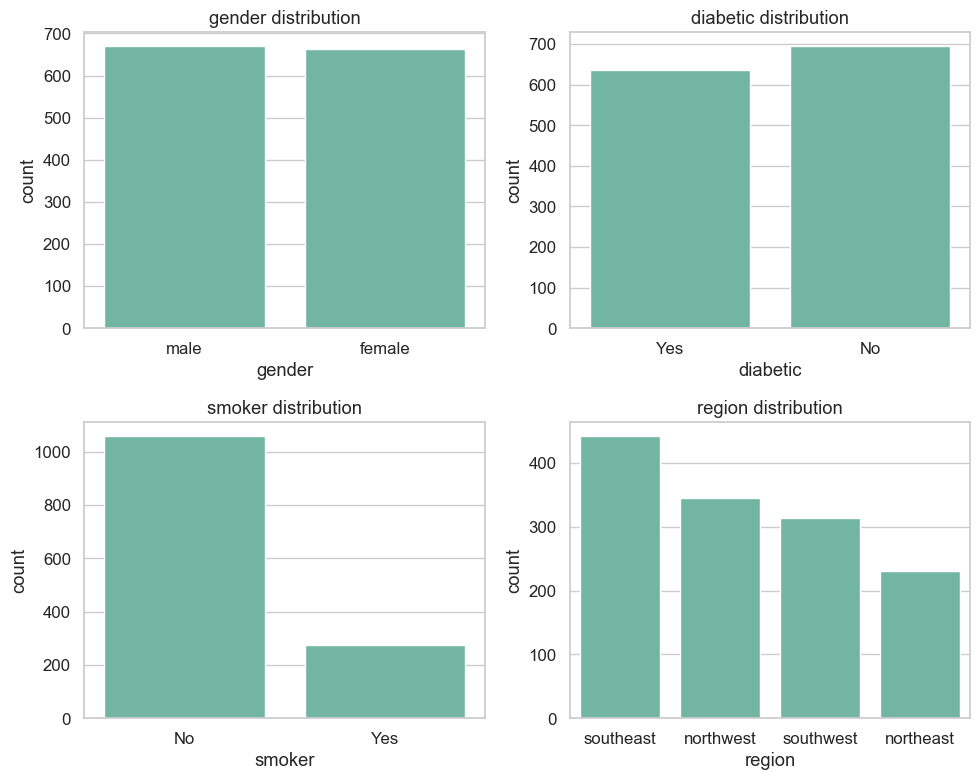

In [48]:
plt.figure(figsize=(10,8))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f"{col} distribution")
    
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Smoking Status & Claim Amount')

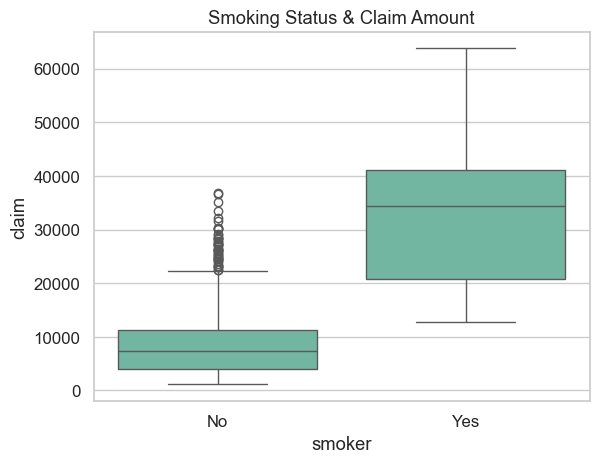

In [103]:
sns.boxplot(data=df, x='smoker', y='claim')
plt.title("Smoking Status & Claim Amount")

In [67]:
gender_smoker_pivot = df.groupby(['gender', 'smoker'])['claim'].mean().round(2).unstack()
gender_smoker_pivot

smoker,No,Yes
gender,,
female,8762.30,30679.00
male,8169.25,33042.01


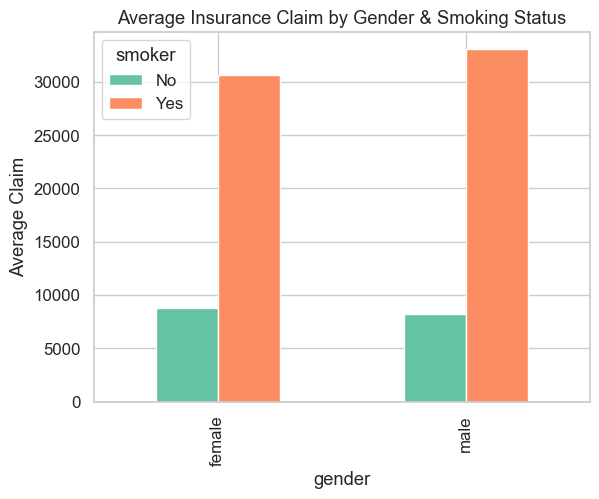

In [62]:
gender_smoker_pivot.plot(kind='bar')
plt.title("Average Insurance Claim by Gender & Smoking Status")
plt.ylabel("Average Claim")
plt.show()

In [66]:
region_diabetic_pivot = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()
region_diabetic_pivot

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


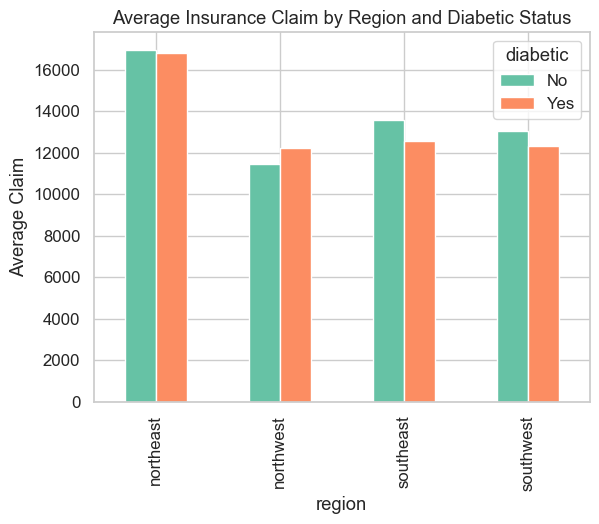

In [60]:
region_diabetic_pivot.plot(kind="bar")
plt.title("Average Insurance Claim by Region and Diabetic Status")
plt.ylabel("Average Claim")
plt.show()

In [65]:
region_smoker_pivot = df.groupby(['region', 'smoker'])['claim'].mean().round(2).unstack()
region_smoker_pivot

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


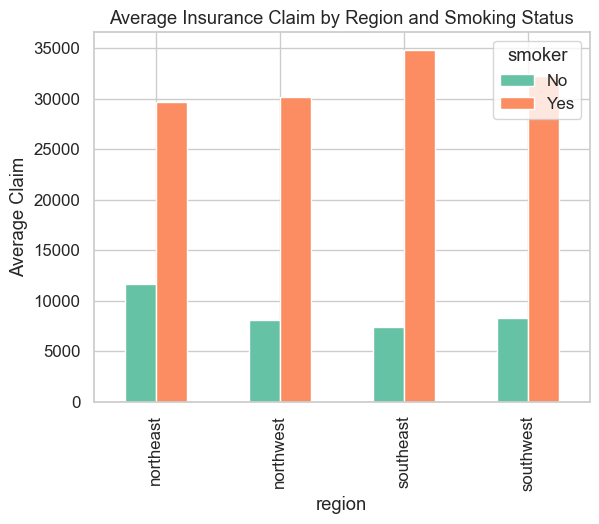

In [68]:
region_smoker_pivot.plot(kind='bar')
plt.title('Average Insurance Claim by Region and Smoking Status')
plt.ylabel("Average Claim")
plt.show()

Text(0, 0.5, '')

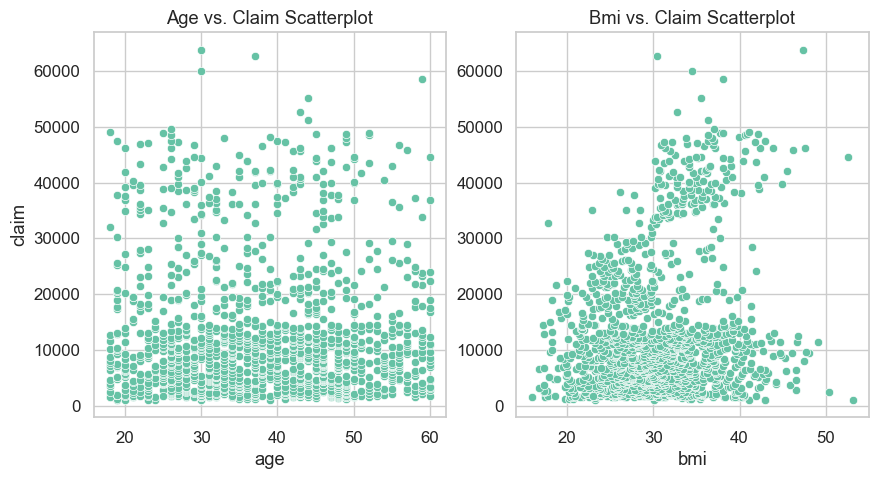

In [99]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

sns.scatterplot(ax=axs[0], data=df, x='age', y='claim')
axs[0].set_title('Age vs. Claim Scatterplot')

sns.scatterplot(ax=axs[1], data=df, x='bmi', y='claim')
axs[1].set_title('Bmi vs. Claim Scatterplot')
axs[1].set_ylabel("")


Text(0, 0.5, '')

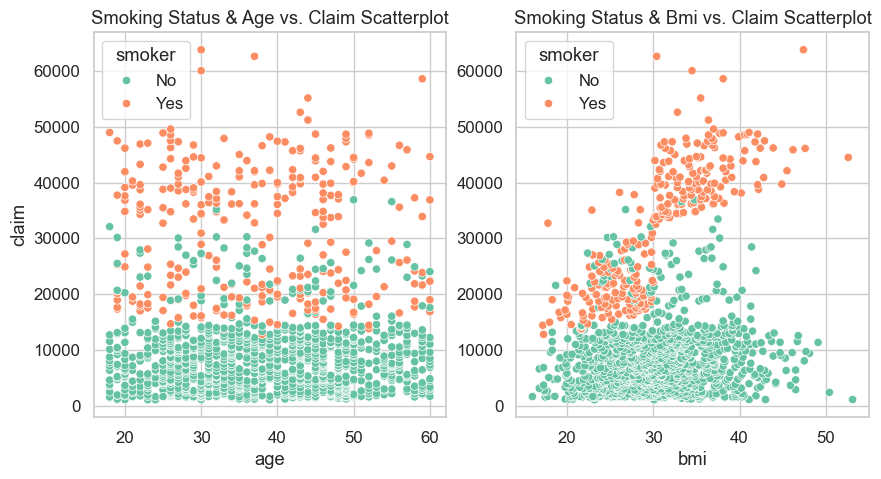

In [101]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

sns.scatterplot(ax=axs[0], data=df, x='age', y='claim', hue='smoker')
axs[0].set_title('Smoking Status & Age vs. Claim Scatterplot')

sns.scatterplot(ax=axs[1], data=df, x='bmi', y='claim', hue='smoker')
axs[1].set_title('Smoking Status & Bmi vs. Claim Scatterplot')
axs[1].set_ylabel("")

Text(0.5, 1.0, 'Claim Distribution by # of Children')

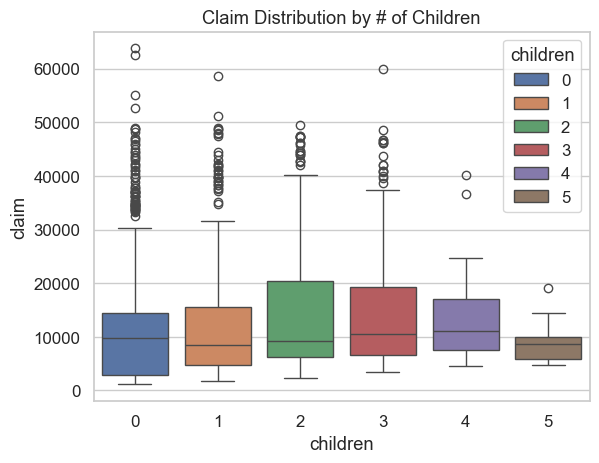

In [127]:
sns.boxplot(data=df, x='children', y='claim', hue='children', palette='deep')
plt.title('Claim Distribution by # of Children')

In [128]:
children_smoker_pivot = df.groupby(['children', 'smoker'])['claim'].mean().round(2).unstack()
children_smoker_pivot

smoker,No,Yes
children,,
0,7698.05,31341.36
1,8303.11,31822.65
2,9493.09,33844.24
3,9614.52,32724.92
4,12121.34,26532.28
5,8183.85,19023.26


In [129]:
children_diabetic_pivot = df.groupby(['children', 'diabetic'])['claim'].mean().round(2).unstack()
children_diabetic_pivot

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


Text(0.5, 1.0, 'Numerical Features Correlation Heatmap')

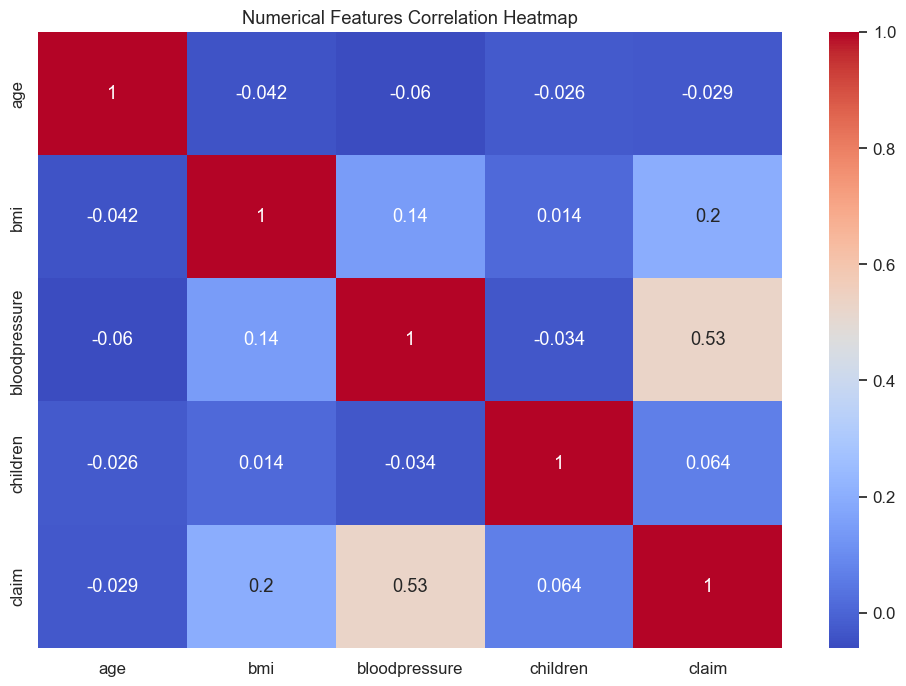

In [123]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Numerical Features Correlation Heatmap')

In [134]:
df['age_group'] = pd.cut(df['age'], bins=[0,18,30,45,60,100], labels=['<18', '18-30', '31-45', '46-60', '60+'])
df['age_group'].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

Text(0.5, 1.0, 'Average Claim by Age Group')

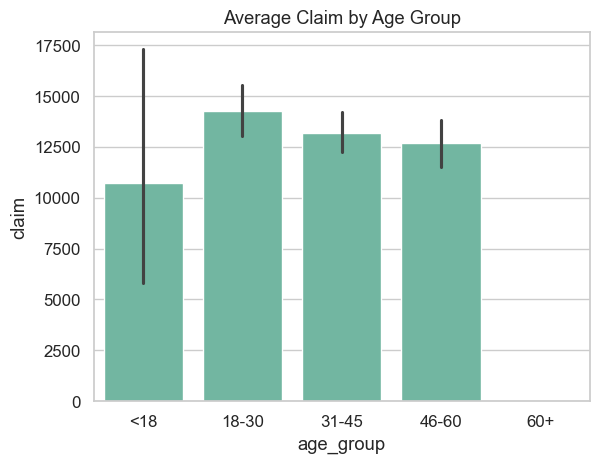

In [131]:
sns.barplot(data=df, x='age_group', y='claim', estimator='mean')
plt.title("Average Claim by Age Group")

In [135]:
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['underweight', 'normal', 'overweight', 'obese'])
df['bmi_category'].value_counts()

bmi_category
obese          702
overweight     387
normal         222
underweight     21
Name: count, dtype: int64

Text(0.5, 1.0, 'Average Claim by Bmi Category')

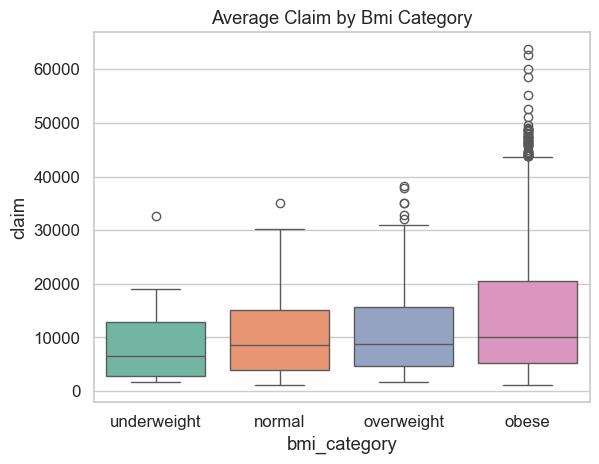

In [147]:
sns.boxplot(data=df, x='bmi_category', y='claim', hue='bmi_category')
plt.title("Average Claim by Bmi Category")

Text(0.5, 1.0, 'Average Claim by Bmi Category & Smoking Status')

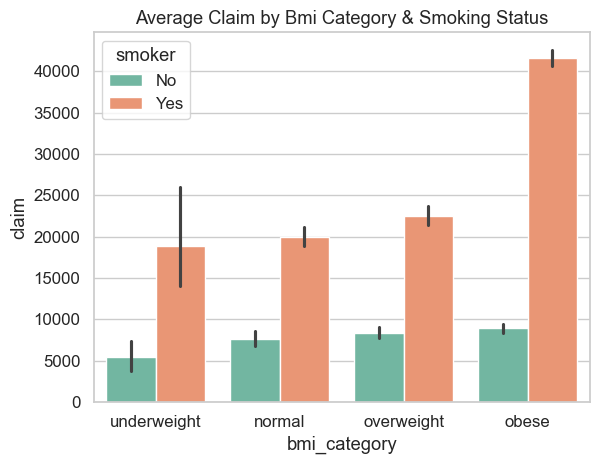

In [ ]:
sns.barplot(data=df, x='bmi_category', y='claim', estimator='mean', hue='smoker')
plt.title("Average Claim by Bmi Category & Smoking Status")